In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [58]:
df = pd.read_csv("./PhotonDetector/build/2mm_2mm_1k_photon_boundaries.csv")


In [59]:
df['volumeName'].unique()

<StringArray>
['physPhotonDetectorNegX', 'physPhotonDetectorPosY', 'physPhotonDetectorPosX',
              'physWater', 'physPhotonDetectorNegY',               'physGlue',
 'physPhotonDetectorNegZ', 'physPhotonDetectorPosZ']
Length: 8, dtype: str

In [60]:
df.head()

,eventID,trackID,parentID,particleName,originCode,originLabel,originIsotope,creatorProcess,boundary,volumeName,...,z_mm,px,py,pz,kineticEnergy_MeV,time_s,gammaEmittedX_mm,gammaEmittedY_mm,gammaEmittedZ_mm,sourceVolumeName
0,0,1475,1115,gamma,72,gammaBi214,Bi214,RadioactiveDecay,enter,physPhotonDetectorNegX,...,442.4240,-0.446685,-0.113594,0.887451,0.068670,590370.0,-24.80390,93.1591,5.45558,logicWater
1,0,1475,1115,gamma,72,gammaBi214,Bi214,RadioactiveDecay,exit,physPhotonDetectorNegX,...,442.4240,-0.446685,-0.113594,0.887451,0.068670,590370.0,-24.80390,93.1591,5.45558,logicWater
2,0,1857,1854,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,physPhotonDetectorPosY,...,-68.0123,0.160921,0.930039,-0.330350,0.768361,590387.0,-24.80550,93.1610,5.45698,logicWater
3,0,1857,1854,gamma,73,gammaPo214,Po214,RadioactiveDecay,exit,physPhotonDetectorPosY,...,-68.0123,0.160921,0.930039,-0.330350,0.768361,590387.0,-24.80550,93.1610,5.45698,logicWater
4,1,1475,1126,gamma,72,gammaBi214,Bi214,RadioactiveDecay,enter,physPhotonDetectorPosY,...,-702.3420,-0.199013,0.326931,-0.923856,0.047702,1980730.0,-9.64653,-31.5214,97.93930,logicWater


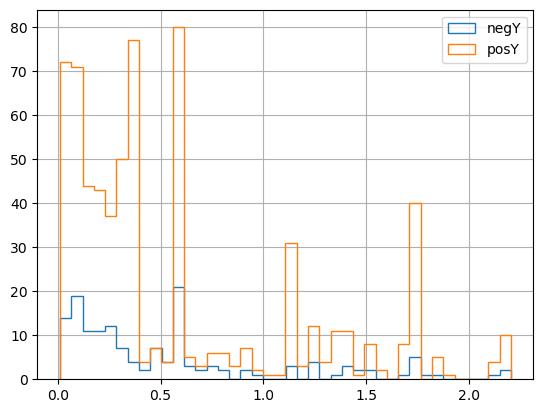

In [61]:
df[(df['volumeName']=='physPhotonDetectorNegY') & (df['boundary']=='enter')]['kineticEnergy_MeV'].hist(bins=40, histtype=u'step', label='negY')
df[(df['volumeName']=='physPhotonDetectorPosY') & (df['boundary']=='enter')]['kineticEnergy_MeV'].hist(bins=40, histtype=u'step', label='posY')
plt.legend()
plt.show()

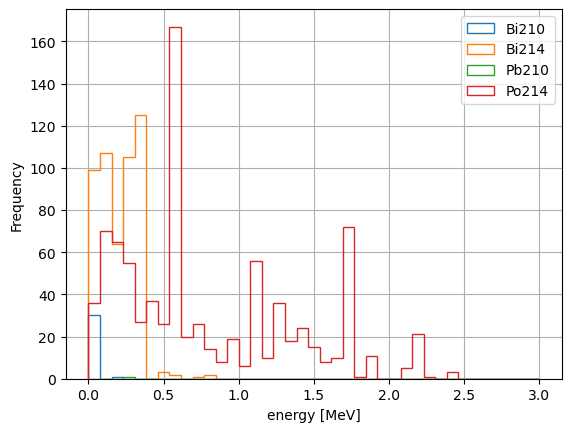

In [62]:
grouped_en = df[(df['volumeName'].str.contains('physPhotonDetector')) & (df['boundary']=='enter')].groupby(['originIsotope'])['kineticEnergy_MeV']
grouped_en.plot(kind='hist', bins=np.linspace(0, 3, 40), histtype='step')
plt.xlabel('energy [MeV]')
plt.legend(loc='upper right')
plt.grid()
plt.show()

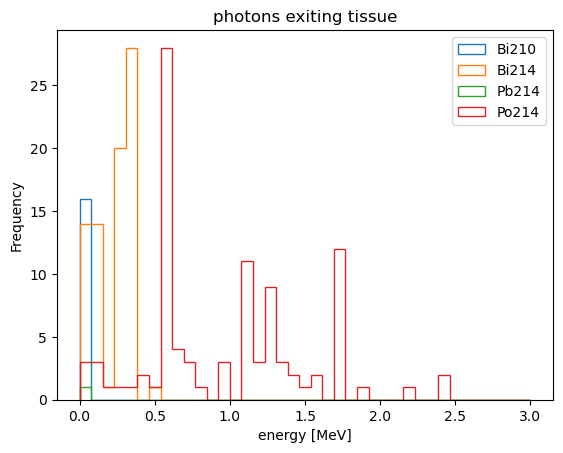

In [63]:
grouped_en = df[(df['volumeName'].str.contains('physWater')) & (df['boundary']=='exit')].groupby(['originIsotope'])['kineticEnergy_MeV']
grouped_en.plot(kind='hist', bins=np.linspace(0, 3, 40), histtype='step', title='photons exiting tissue')
plt.xlabel('energy [MeV]')
plt.legend()

plt.show()

In [64]:
df[df['originIsotope']=='Pb214']['kineticEnergy_MeV']*1e3

328    24.0086
329    24.0086
Name: kineticEnergy_MeV, dtype: float64

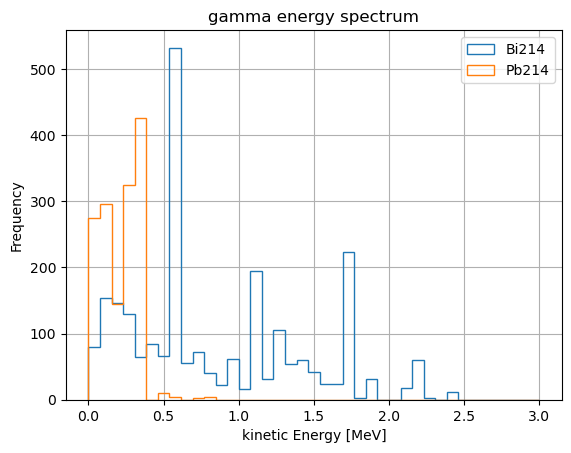

In [65]:
(df[df['originIsotope']=='Po214']['kineticEnergy_MeV']).plot(kind='hist', bins=np.linspace(0, 3, 40), histtype=u'step', label='Bi214')
(df[df['originIsotope']=='Bi214']['kineticEnergy_MeV']).plot(kind='hist', bins=np.linspace(0, 3, 40), histtype=u'step', label='Pb214')
plt.legend()
plt.title('gamma energy spectrum')
plt.xlabel('kinetic Energy [MeV]')
plt.grid()
plt.show()

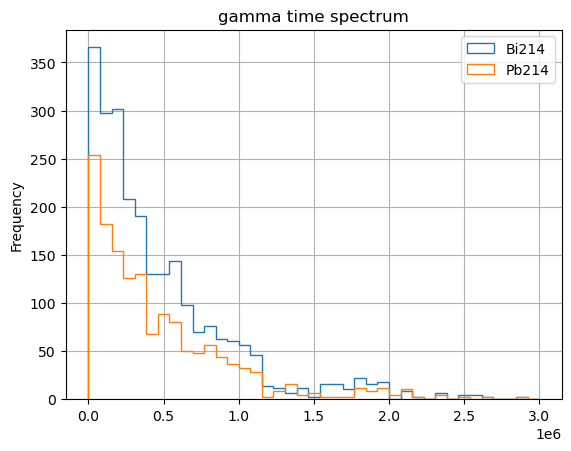

In [66]:
(df[df['originIsotope']=='Po214']['time_s']).plot(kind='hist', bins=np.linspace(0, 3e6, 40), histtype=u'step', label='Bi214')
(df[df['originIsotope']=='Bi214']['time_s']).plot(kind='hist', bins=np.linspace(0, 3e6, 40), histtype=u'step', label='Pb214')
plt.legend()
plt.grid()
plt.title('gamma time spectrum')
plt.show()

In [67]:
df[df['volumeName']=='physPhotonDetectorPosX']

,eventID,trackID,parentID,particleName,originCode,originLabel,originIsotope,creatorProcess,boundary,volumeName,...,z_mm,px,py,pz,kineticEnergy_MeV,time_s,gammaEmittedX_mm,gammaEmittedY_mm,gammaEmittedZ_mm,sourceVolumeName
8,3,1256,1123,gamma,72,gammaBi214,Bi214,RadioactiveDecay,enter,physPhotonDetectorPosX,...,41.2611,0.946621,-0.269651,0.176626,0.351932,646699.0,73.49070,74.1047,-1.002280,logicWater
9,3,1256,1123,gamma,72,gammaBi214,Bi214,RadioactiveDecay,exit,physPhotonDetectorPosX,...,41.2611,0.946621,-0.269651,0.176626,0.351932,646699.0,73.49070,74.1047,-1.002280,logicWater
60,17,1918,1541,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,physPhotonDetectorPosX,...,99.2759,0.930523,-0.128954,0.342779,0.376643,393152.0,-20.87100,83.5789,38.474800,logicWater
61,17,1918,1541,gamma,73,gammaPo214,Po214,RadioactiveDecay,exit,physPhotonDetectorPosX,...,99.2759,0.930523,-0.128954,0.342779,0.376643,393152.0,-20.87100,83.5789,38.474800,logicWater
62,17,2634,1917,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,physPhotonDetectorPosX,...,-97.5509,0.791039,-0.511666,-0.335342,0.609315,393152.0,-20.87100,83.5789,38.474800,logicWater
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3991,90,2192,1719,gamma,73,gammaPo214,Po214,RadioactiveDecay,exit,physPhotonDetectorPosX,...,73.6364,0.870733,-0.439745,0.220110,0.633151,331578.0,5.95863,101.7350,-0.693578,logicGlue
4004,92,1702,1484,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,physPhotonDetectorPosX,...,-145.0560,0.859085,-0.223852,-0.460287,1.120290,776374.0,-3.71281,40.9968,17.669900,logicWater
4005,92,1702,1484,gamma,73,gammaPo214,Po214,RadioactiveDecay,exit,physPhotonDetectorPosX,...,-145.0560,0.859085,-0.223852,-0.460287,1.120290,776374.0,-3.71281,40.9968,17.669900,logicWater
4016,96,1927,1924,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,physPhotonDetectorPosX,...,237.7980,0.811401,0.067776,0.580546,0.609315,1939440.0,-7.78346,100.3810,17.583100,logicGlue


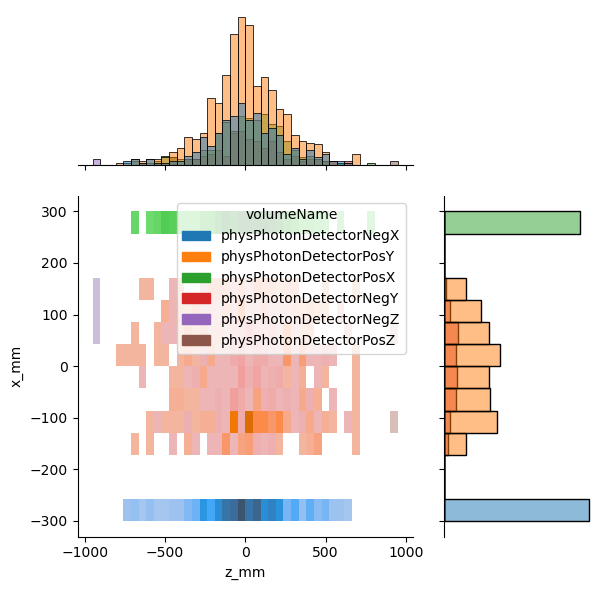

In [68]:
sns.jointplot(data=df[(df['volumeName'].str.contains('physPhotonDetector'))&(df['boundary']=='enter')], x='z_mm', y='x_mm', kind='hist', hue='volumeName', ratio=2)

plt.show()

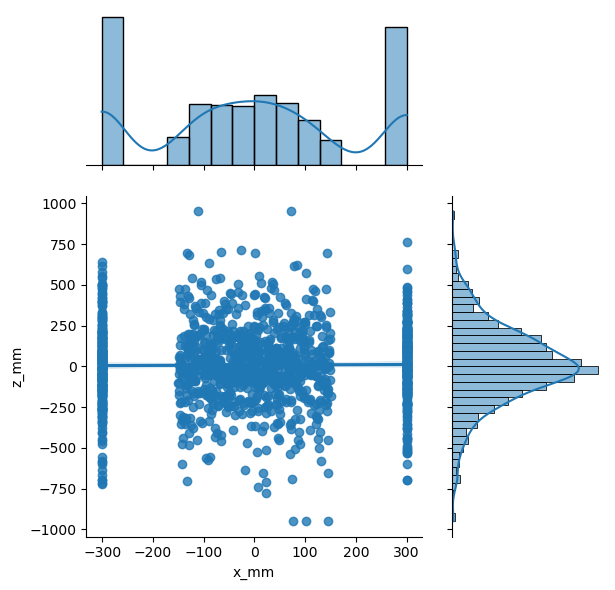

In [69]:
sns.jointplot(data=df[(df['volumeName'].str.contains('physPhotonDetector'))&(df['boundary']=='enter')], x='x_mm', y='z_mm', kind='reg', ratio=2)

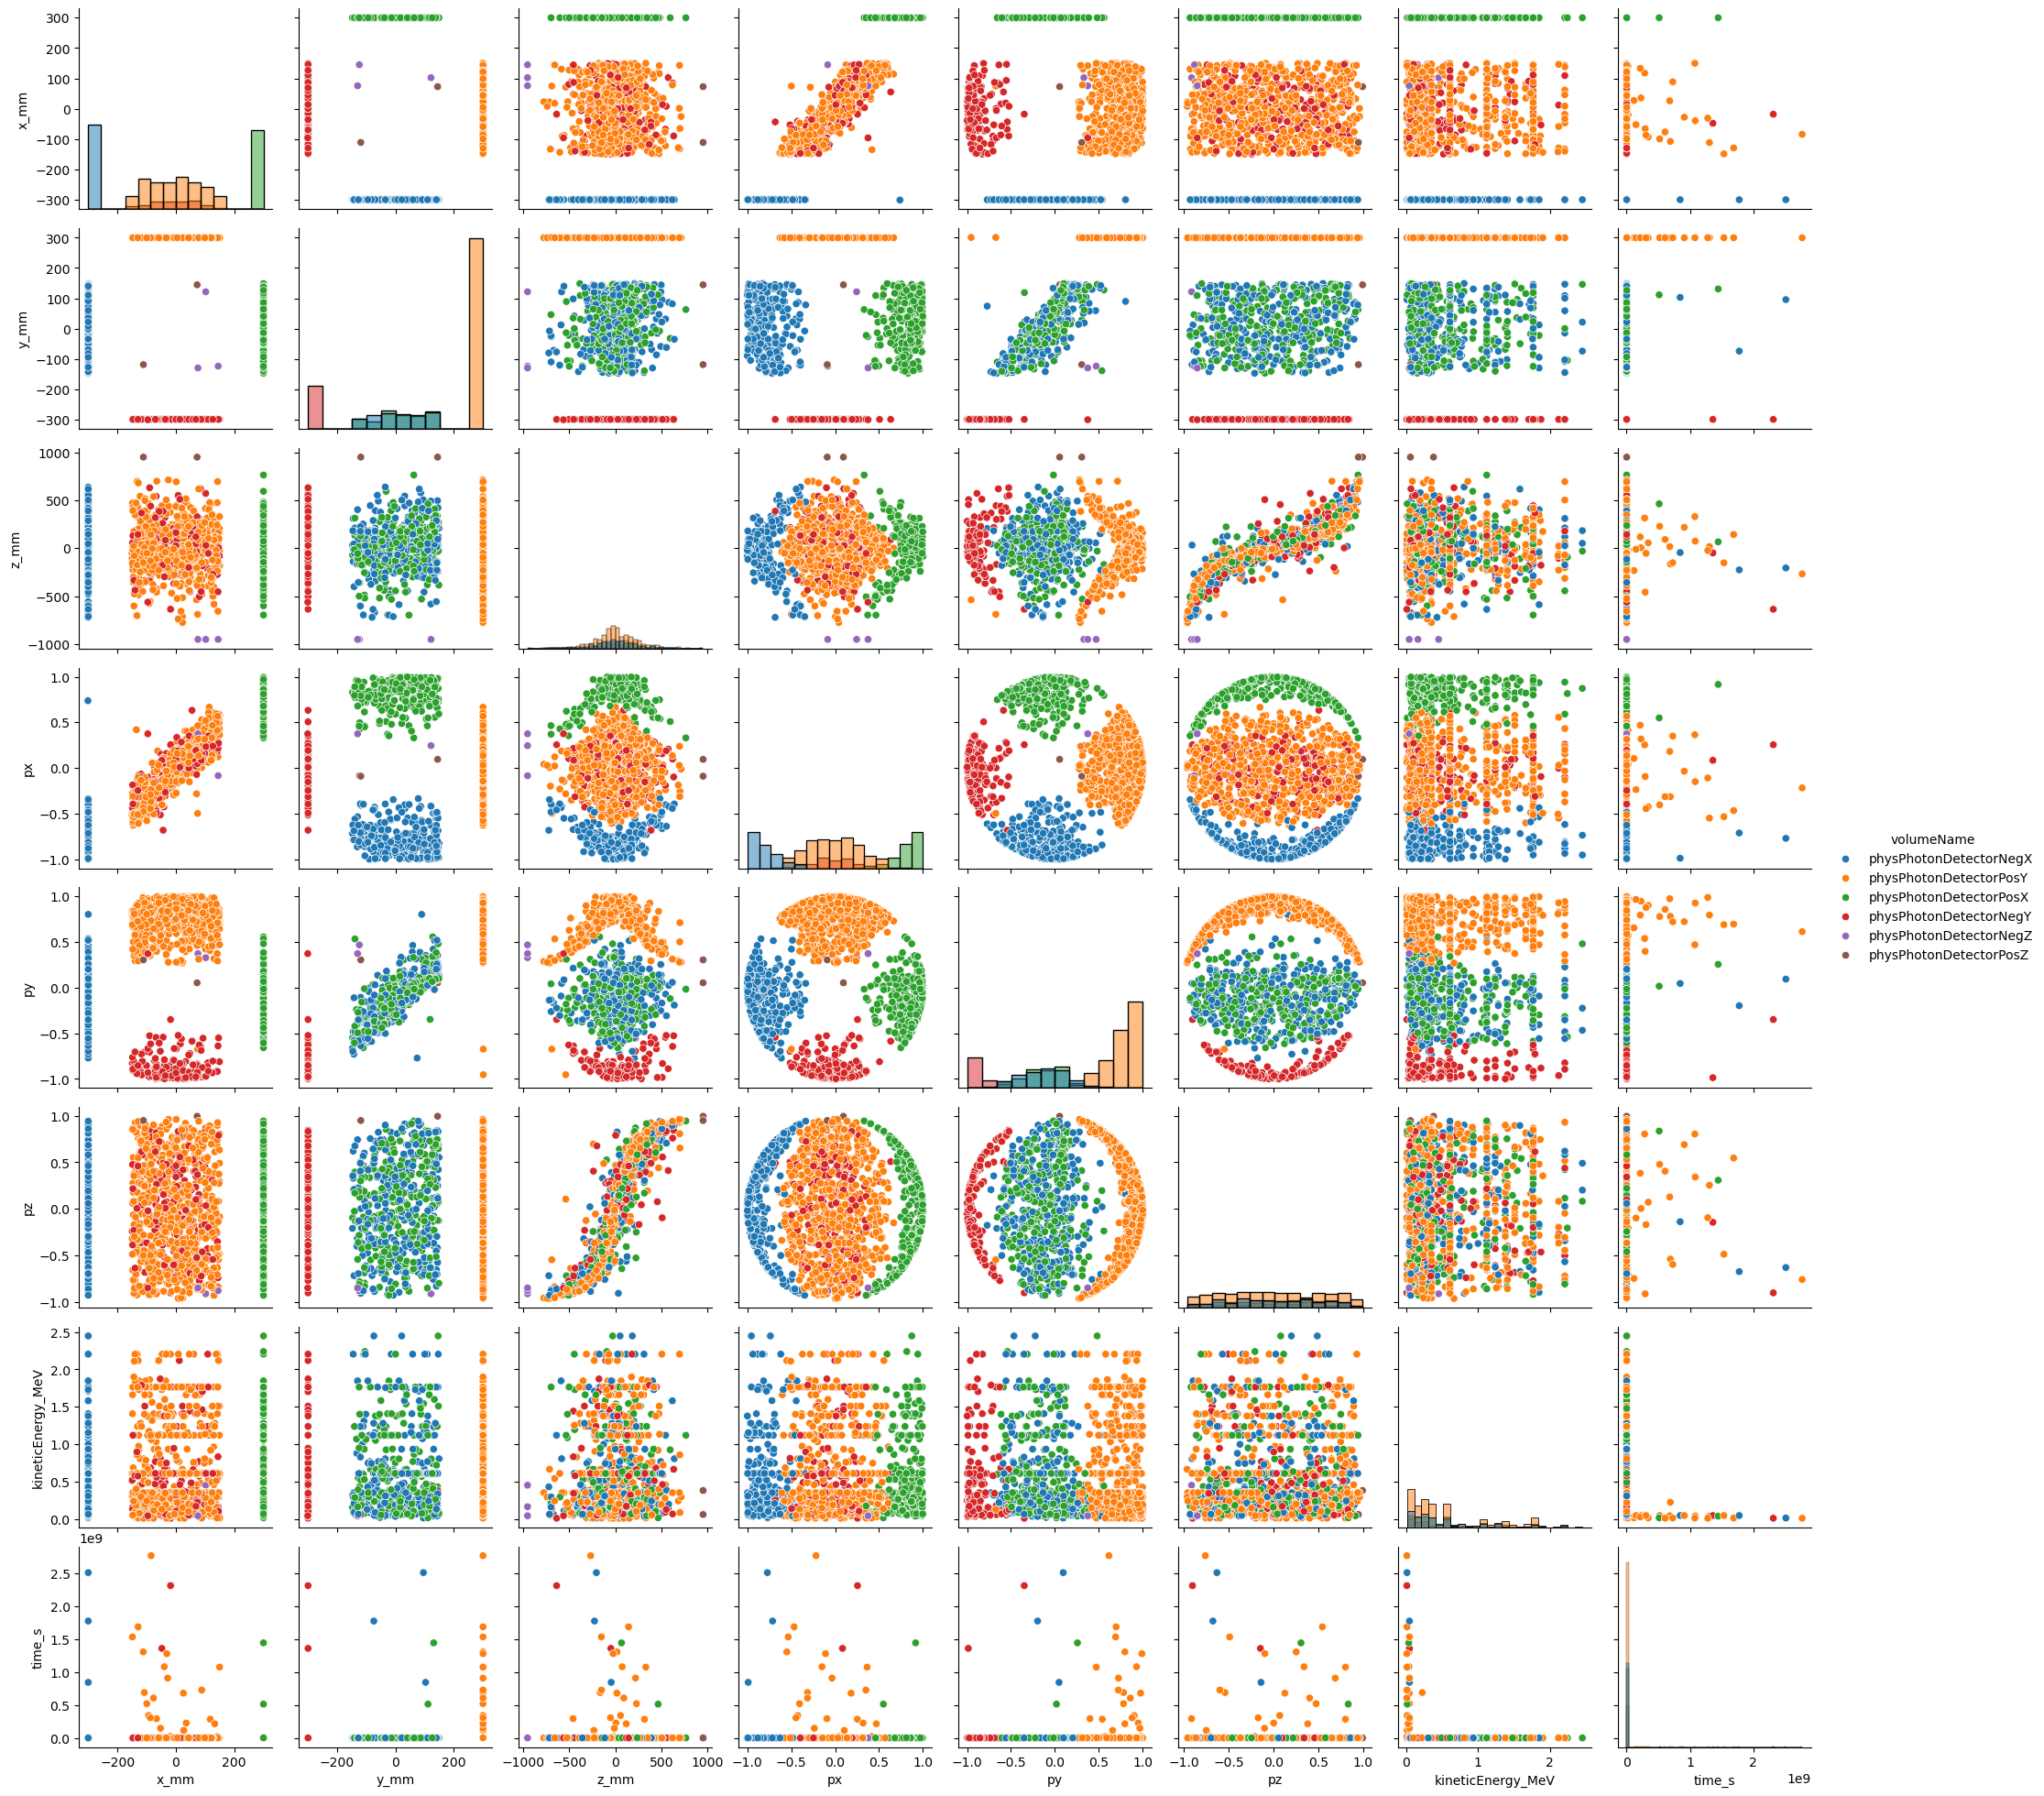

In [70]:
plot_df =df[(df['volumeName'].str.contains('physPhotonDetector'))&(df['boundary']=='enter')]
variables = ['x_mm', 'y_mm', 'z_mm', 'px', 'py', 'pz','kineticEnergy_MeV', 'time_s']
g = sns.PairGrid(plot_df, hue='volumeName', vars=variables)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()

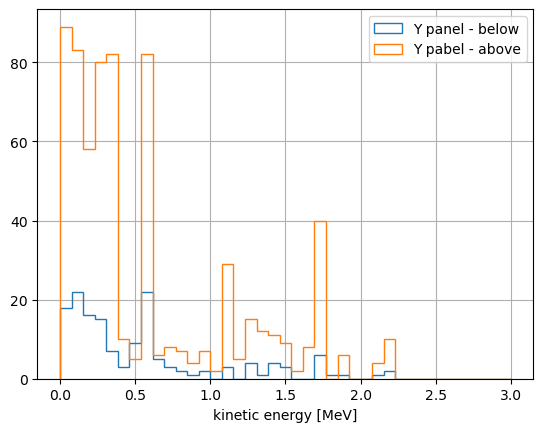

In [71]:
#energy spectrum per panel
bins=np.linspace(0, 3, 40)
df[(df['volumeName']=='physPhotonDetectorNegY') & (df['boundary']=='enter')]['kineticEnergy_MeV'].hist(bins=bins, histtype=u'step', label='Y panel - below')
df[(df['volumeName']=='physPhotonDetectorPosY') & (df['boundary']=='enter')]['kineticEnergy_MeV'].hist(bins=bins, histtype=u'step', label='Y pabel - above')
plt.legend()
plt.xlabel("kinetic energy [MeV]")
plt.show()

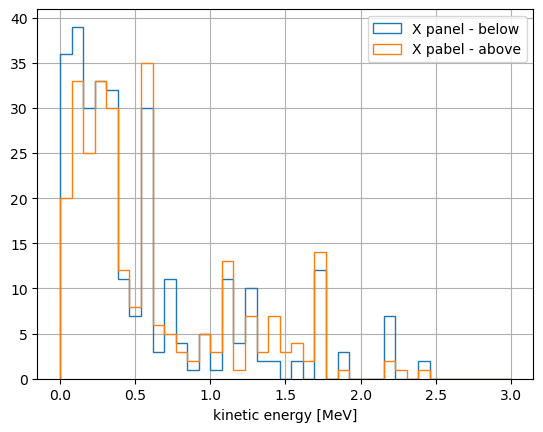

In [72]:
bins=np.linspace(0, 3, 40)
df[(df['volumeName']=='physPhotonDetectorNegX') & (df['boundary']=='enter')]['kineticEnergy_MeV'].hist(bins=bins, histtype=u'step', label='X panel - below')
df[(df['volumeName']=='physPhotonDetectorPosX') & (df['boundary']=='enter')]['kineticEnergy_MeV'].hist(bins=bins, histtype=u'step', label='X pabel - above')
plt.legend()
plt.xlabel("kinetic energy [MeV]")
plt.show()

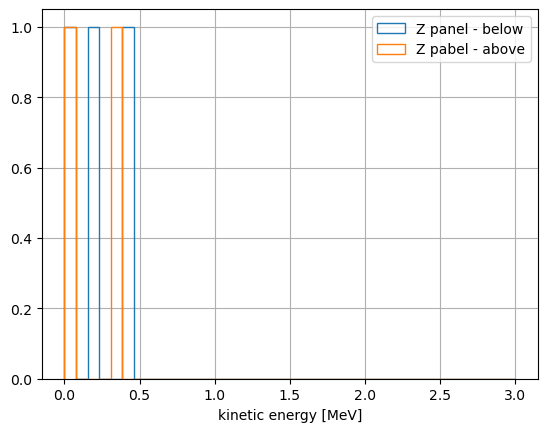

In [73]:
bins=np.linspace(0, 3, 40)
df[(df['volumeName']=='physPhotonDetectorNegZ') & (df['boundary']=='enter')]['kineticEnergy_MeV'].hist(bins=bins, histtype=u'step', label='Z panel - below')
df[(df['volumeName']=='physPhotonDetectorPosZ') & (df['boundary']=='enter')]['kineticEnergy_MeV'].hist(bins=bins, histtype=u'step', label='Z pabel - above')
plt.legend()
plt.xlabel("kinetic energy [MeV]")
plt.show()

In [74]:
df_2mm_fully = pd.read_csv("./PhotonDetector/build/2mm_2mm_1k_photon_boundaries.csv")
df_2mm_50um_bottom = pd.read_csv("./PhotonDetector/build/2mm_50um_bottom_1k_photon_boundaries.csv")

In [75]:
def plot_photons_vs_distance(df, get_hist=False, title=None):    
    bins=np.linspace(-1500, 1500, 60)
    fig, axs = plt.subplots(3, sharex=True, figsize=(8,5))
    fig.suptitle(title)
    xpos= df[(df['volumeName']=='physPhotonDetectorPosY') & (df['boundary']=='enter')]['x_mm']
    xneg= df[(df['volumeName']=='physPhotonDetectorNegY') & (df['boundary']=='enter')]['x_mm']
    zpos = df[(df['volumeName']=='physPhotonDetectorPosY') & (df['boundary']=='enter')]['z_mm']
    zneg = df[(df['volumeName']=='physPhotonDetectorNegY') & (df['boundary']=='enter')]['z_mm']
    axs[0].hist2d(zpos.to_numpy(), xpos.to_numpy(), bins=bins, cmap='Oranges')
    axs[0].set_ylabel('x pos [mm]')
    axs[0].set_ylim((-500,500))
    axs[0].text(x=1250,y=350, s='PosY', fontsize='medium')

    axs[1].hist(zneg, bins=bins, histtype=u'step', label='Y panel - below', linewidth=2)
    axs[1].hist(zpos, bins=bins, histtype=u'step', label='Y panel - above', linewidth=2)
    axs[1].legend(loc='upper right', fontsize='small')
    axs[1].set_ylabel('counts')

    axs[2].hist2d(zneg.to_numpy(), xneg.to_numpy(), bins=bins, cmap='Blues')
    axs[2].set_ylabel('x pos [mm]')
    axs[2].set_ylim((-500,500))
    axs[2].text(x=1250,y=350, s='NegY', fontsize='medium')

    plt.xlabel("z pos [mm]")

    plt.show()
    if get_hist:
        return zneg, zpos

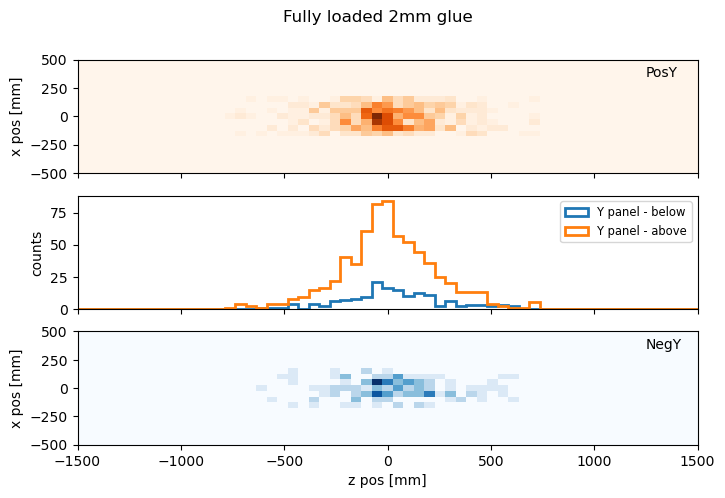

In [76]:
plot_photons_vs_distance(df_2mm_fully, title='Fully loaded 2mm glue')

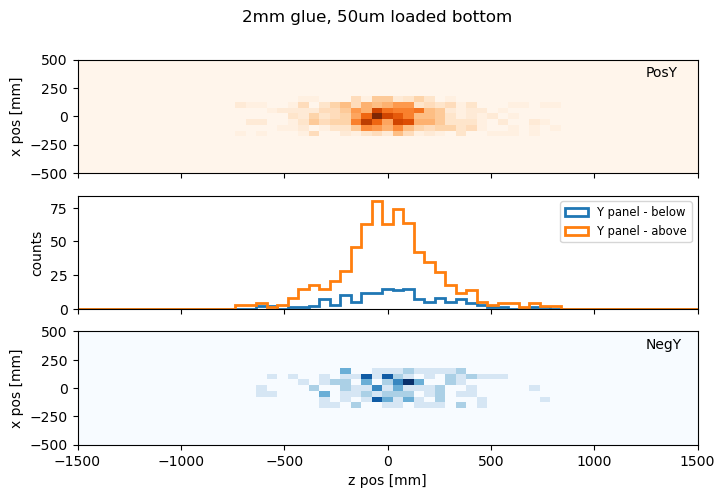

In [77]:
plot_photons_vs_distance(df_2mm_50um_bottom, title='2mm glue, 50um loaded bottom')

In [78]:
df_2mm_fully_10k = pd.read_csv("./PhotonDetector/build/2mm_2mm_10k_photon_boundaries.csv")
df_2mm_50um_bottom_10k = pd.read_csv("./PhotonDetector/build/2mm_50um_bottom_10k_photon_boundaries.csv")

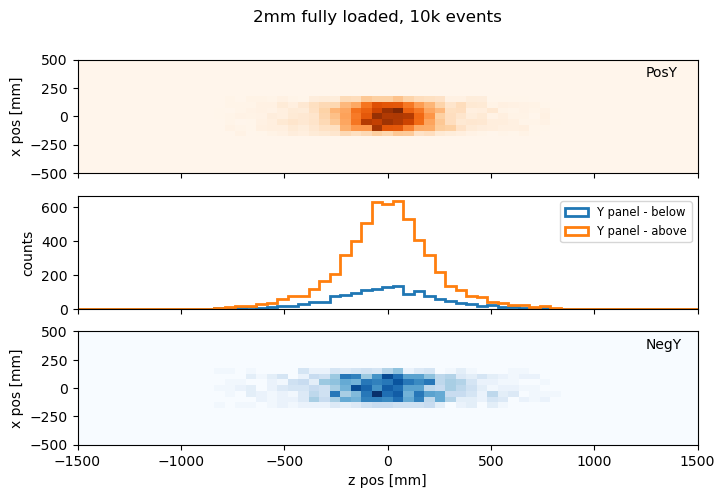

In [79]:
zpos_fully_2mm, zneg_fully_2mm = plot_photons_vs_distance(df_2mm_fully_10k,  title='2mm fully loaded, 10k events', get_hist=True)

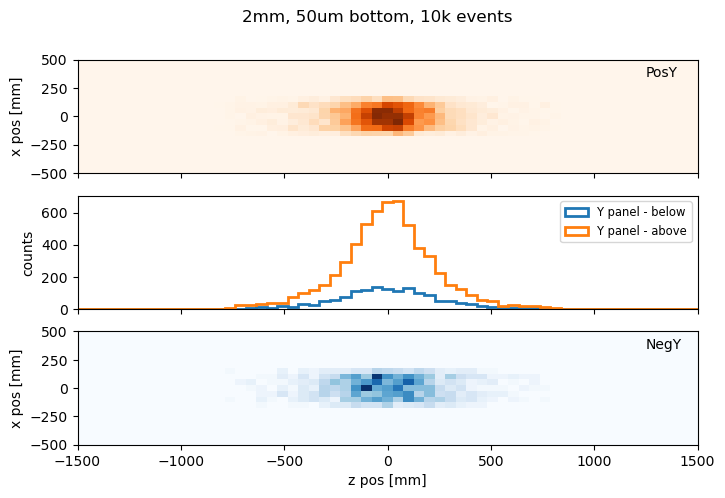

In [80]:
zpos_50umbot, zneg_50umbot = plot_photons_vs_distance(df_2mm_50um_bottom_10k, title='2mm, 50um bottom, 10k events', get_hist=True)

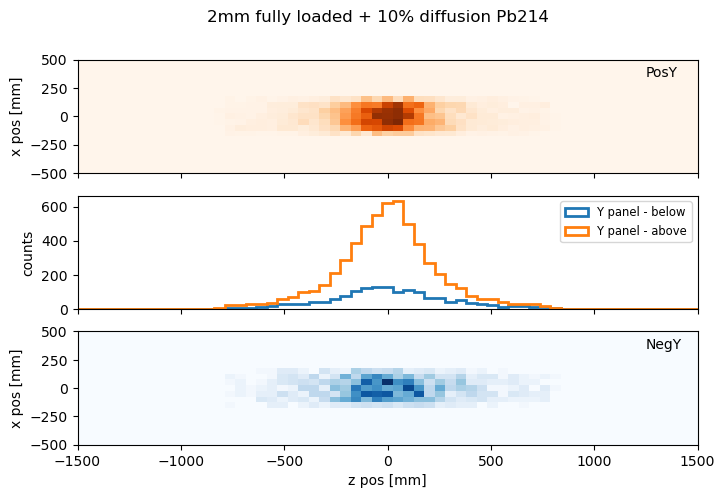

In [ ]:
df_2mm_fully_10k_214p_diff_10 = pd.read_csv("./PhotonDetector/build/2mm_2mm_10k_214pb_diff_10_photon_boundaries.csv")
zneg_diff10, zpos_diff10 = plot_photons_vs_distance(df_2mm_fully_10k_214p_diff_10, get_hist=True, title='2mm fully loaded + 10% diffusion Pb214')

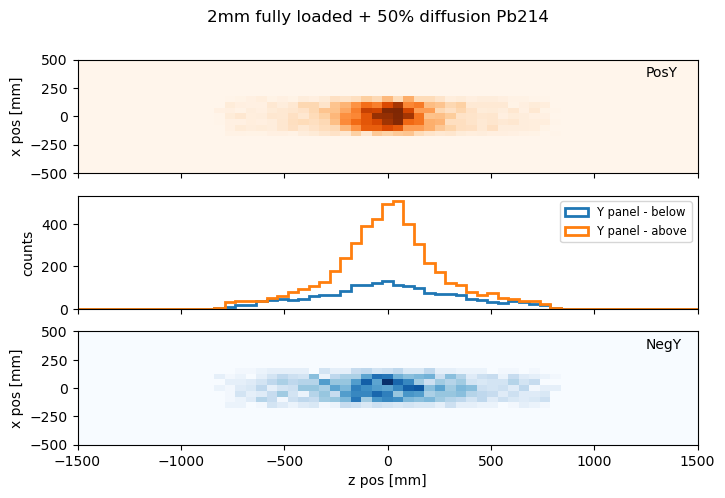

In [82]:
df_2mm_fully_10k_214p_diff_50 = pd.read_csv("./PhotonDetector/build/2mm_2mm_10k_214pb_diff_50_photon_boundaries.csv")
zneg_diff50, zpos_diff50 = plot_photons_vs_distance(df_2mm_fully_10k_214p_diff_50, get_hist=True, title='2mm fully loaded + 50% diffusion Pb214')

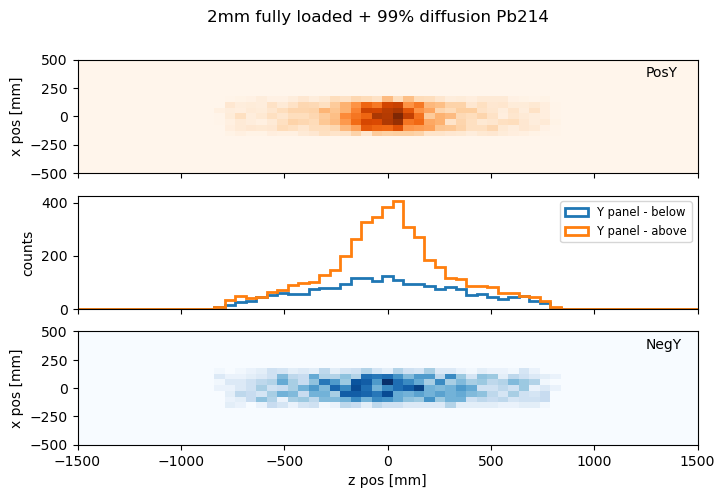

In [83]:
df_2mm_fully_10k_214p_diff_99 = pd.read_csv("./PhotonDetector/build/2mm_2mm_10k_214pb_diff_99_photon_boundaries.csv")

zneg_diff99, zpos_diff99 = plot_photons_vs_distance(df_2mm_fully_10k_214p_diff_99, get_hist=True, title='2mm fully loaded + 99% diffusion Pb214')

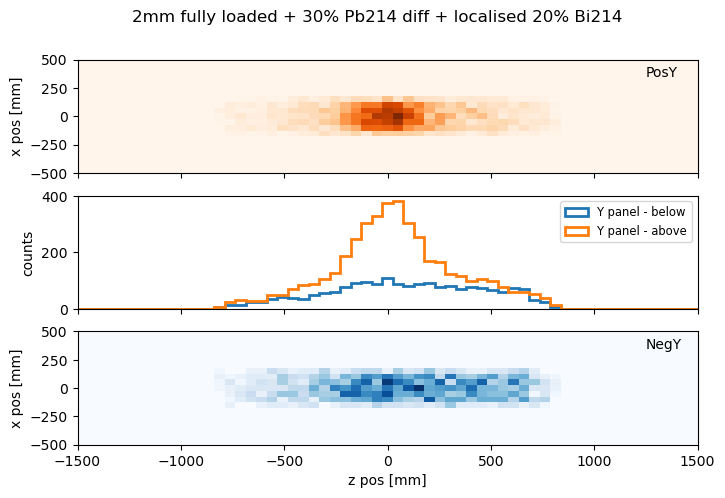

In [84]:
df_2mm_fully_10k_30_20 = pd.read_csv("./PhotonDetector/build/2mm_2mm_10k_30_20_photon_boundaries.csv")
zneg_diff3020, zpos_diff3020 = plot_photons_vs_distance(df_2mm_fully_10k_30_20, get_hist=True, title='2mm fully loaded + 30% Pb214 diff + localised 20% Bi214')

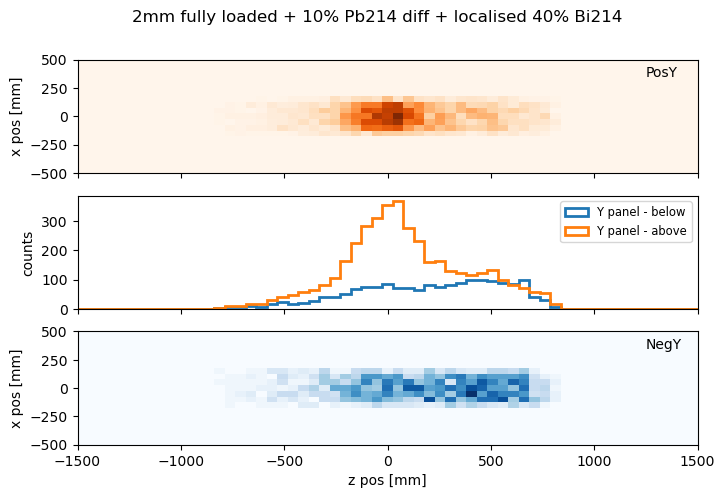

In [85]:
df_2mm_fully_10k_10_40 = pd.read_csv("./PhotonDetector/build/2mm_2mm_10k_1040_photon_boundaries.csv")
zneg_diff1040, zpos_diff1040 = plot_photons_vs_distance(df_2mm_fully_10k_10_40, get_hist=True, title='2mm fully loaded + 10% Pb214 diff + localised 40% Bi214')

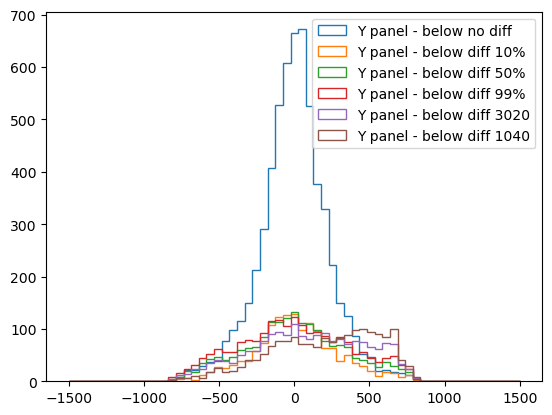

In [86]:
plt.figure()
bins=np.linspace(-1500, 1500, 60)
plt.hist(zneg_50umbot, bins=bins, histtype=u'step', label='Y panel - below no diff', linewidth=1)
plt.hist(zneg_diff10, bins=bins, histtype=u'step', label='Y panel - below diff 10%', linewidth=1)
plt.hist(zneg_diff50, bins=bins, histtype=u'step', label='Y panel - below diff 50%', linewidth=1)
plt.hist(zneg_diff99, bins=bins, histtype=u'step', label='Y panel - below diff 99%', linewidth=1)
plt.hist(zneg_diff3020, bins=bins, histtype=u'step', label='Y panel - below diff 3020', linewidth=1)
plt.hist(zneg_diff1040, bins=bins, histtype=u'step', label='Y panel - below diff 1040', linewidth=1)
plt.legend()
plt.show()

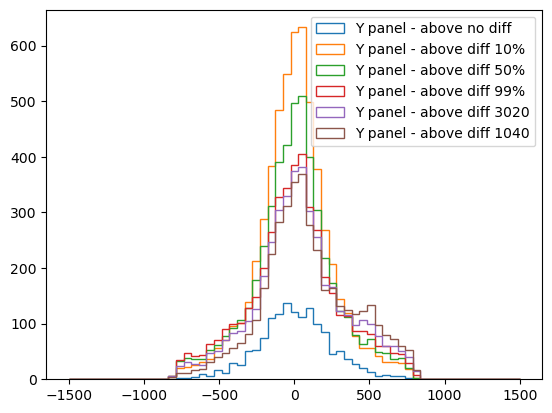

In [87]:
plt.figure()
bins=np.linspace(-1500, 1500, 60)
plt.hist(zpos_50umbot, bins=bins, histtype=u'step', label='Y panel - above no diff', linewidth=1)
plt.hist(zpos_diff10, bins=bins, histtype=u'step', label='Y panel - above diff 10%', linewidth=1)
plt.hist(zpos_diff50, bins=bins, histtype=u'step', label='Y panel - above diff 50%', linewidth=1)
plt.hist(zpos_diff99, bins=bins, histtype=u'step', label='Y panel - above diff 99%', linewidth=1)
plt.hist(zpos_diff3020, bins=bins, histtype=u'step', label='Y panel - above diff 3020', linewidth=1)
plt.hist(zpos_diff1040, bins=bins, histtype=u'step', label='Y panel - above diff 1040', linewidth=1)
plt.legend()
plt.show()

In [88]:
df_2mm_fully_10k = pd.read_csv("./PhotonDetector/build/2mm_2mm_10k_30_20_photon_boundaries.csv")


In [89]:
def leakage_region(df,  panel='physPhotonDetectorPosY', coord_range=(-600, -800), coord='z_mm'):
    df[(df['volumeName']==panel) 
                 & (df['boundary']=='enter') 
                 & (df[coord] <= coord_range[0]) & (df[coord] >= coord_range[1])
                 ]['z_mm'].hist(histtype=u'step', bins=np.linspace(coord_range[1]-100, coord_range[0]+100, 40))


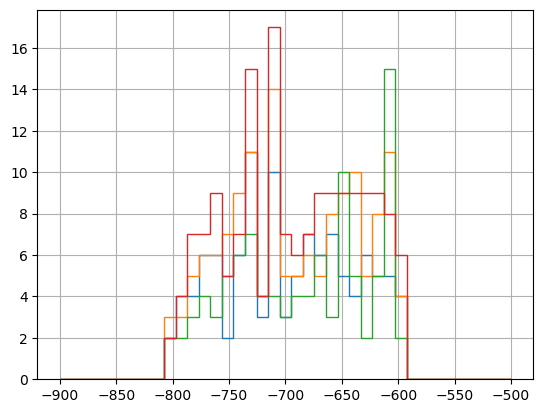

In [90]:
plt.figure()
leakage_region(df_2mm_fully_10k)
leakage_region(df_2mm_fully_10k_214p_diff_50)
leakage_region(df_2mm_fully_10k_214p_diff_10)
leakage_region(df_2mm_fully_10k_214p_diff_99)